# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
import os 
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [6]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENROUTER_API_KEY')
if openai_api_key.startswith("sk-or-"):
    print("API Key succes")
else:
    print("API Key Invalid")

openai_url = "https://openrouter.ai/api/v1"
model = "openai/gpt-4o-mini"
openai = OpenAI(base_url=openai_url, api_key=openai_api_key)

DB = "prices.db"

API Key succes


In [3]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [16]:
def get_ticket_price(city): # mendefinisikan function yang menerima 1 parameter (city) function ini yang nanti di panggil oleh code saat LLM meminta tool
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True) # debugging/log mencetak pesan tiap kali function di panggil, flush=True memaksa text langsung di tulis saat itu juga, karena python menampung (buffer) output print dulu sebelum benar2 menampilkannya, kadang print tertahan dan baru muncul telat atau berantakan urutannya, oleh karena itu menggunakna flush=True
    with sqlite3.connect(DB) as conn: # membuka coneksi ke file prices.db, mengembalikan object conn
        cursor = conn.cursor() # membuat cursor dari koneksi, menjalankan query lewat cursor
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),)) # ambil kolom price dari tabel prices, di mana kolom city dama dengan sesuatu
        result = cursor.fetchone() # mengambil satu baris hasil dari query .fetchone() mengembalikan hasil sebagai tuple, misal(899) atau (none) kalau tidak ada baris yang cocok
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city" # if result: mengecek apakah (result) ada isinya, jika ada (result) berisi tuple (899) "truthy", jika tidak ada maka (none) "falsy" kembalikan "No price data available for this city"

In [18]:
get_ticket_price("tokyo") # test manual call function dengan argument (paris)

DATABASE TOOL CALLED: Getting price for tokyo


'Ticket price to tokyo is $1420.0'

In [19]:
# JSON janky
# mendeskripsikan function kepada LLM dalam bahasa yang di mengerti LLM. (ini tool yang tersedia, ini namanya, ini gunanya, ini bahan yang di butuhkan dll)

price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": { # bahan parameter yang di butuhkan tool 
        "type": "object",
        "properties": { # daftar parameter di dalam object disini hanya ada satu
            "destination_city": {
                "type": "string", # valuenya harus string (nama kota)
                "description": "The city that the customer wants to travel to", 
            }, # menjelaskan LLM apa isi parameter ini, supaya LLM tau value apa yang harus di isi (nama kota), jadi saat user bilang "ke LONDON", llm paham bahwa "london" adalah destination_city
        },
        "required": ["destination_city"], # daftar parameter yang wajib di isi, LLM tau tidak boleh call tool tanpa mengisi kota tujuan, kalau user cuma bilang "aku mau pesan tiket" tanpa menyebut kota, llm akan menjawab sesuai konteks maka LLM belum menggunakan tool, alih alih memangil tool dengan data kosong
        "additionalProperties": False # tidak boleh ada parameter lain di luar yang sudah di daftarkan, mengunci schema LLM tidak mengerang parameter tambahan yang tidak di dukung, ini bagia fitur strict/structured output
    }
}
tools = [{"type": "function", "function": price_function}] # list dari semua tool yang tersedia untuk LLM, saat ini hanya ada 1, jika menambah tool, tinggal menambah element lain ke sini, tiap element di bungkus dengan struktur [{"type": "function", "function":..}], format OPENAI mengizinkan beberapa jenis tool. 
# tools = [
#    {"type": "function", "function": price_function},
#    {"type": "function", "function": booking_function},
#]
tools # menampilkan isi tool 

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [ ]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=model, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/Users/boss88/llm-project/llm_engineering/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/boss88/llm-project/llm_engineering/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/boss88/llm-project/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/boss88/llm-project/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/boss88/llm-project/llm_engineering/.venv/lib/pyth

In [20]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=model, messages=messages, tools=tools)

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=model, messages=messages, tools=tools)

    return response.choices[0].message.content

In [25]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses 

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London
DATABASE TOOL CALLED: Getting price for Tokyo


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this Svelte app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use gpt-image-1-mini, the image generation model behind GPT-5, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 3 cents - don't go crazy with images!

In [ ]:
# Some imports for handling images
# standart libary

import base64 # mengubah data binary (bytes) menjadi text yang aman di kirim lewat media yang cuma bisa handle text (JSON, HTML atau email)
from io import BytesIO # buat file palsu dalam RAM, membungkus (bytes) berprilaku seperti file, jadi image.open() bisa membacanya tanpa harus menyimpan ke hard drive
from PIL import Image # (Pillow) Python Image Library: untuk mengubah (bytes) jadi object yang bisa di tampilkan atau di proses lebih lanjut

# string base64 (dari API)
#   ↓ base64.b64decode()
# bytes gambar mentah
#   ↓ BytesIO() → bungkus jadi "file"
#   ↓ Image.open() → PIL baca "file" itu
# objek Image yang siap ditampilkan

In [83]:
def artist(city):
    image_response = openai.images.generate( # call API Image Generate OpenAI lewat SDK endpoint khusus untuk generate image, hasilnya di simpan di image_response
        model = "openai/gpt-image-1-mini", # model AI
        prompt = "An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant natural style",
        size = "1024x1024", 
        n=1, # jumlah image yang di buat, (n=2) 2 image, (n3) 3 image
    )
    image_base64 = image_response.data[0].b64_json # mengambil data image dari image_response, hasil image bisa beberapa karena n=1 maka data[0] image pertama, .b64_json = data imagenya dalam bentuk string base64
    image_data = base64.b64decode(image_base64) # decode string base64 kembali jadi (bytes) gambar asli (data binary PNG sesungguhnya)
    return Image.open(BytesIO(image_data)) 
    # BytesIO(image_data) = membungkus bytes supaya jadi seperti "file di RAM" lalu
    # Image.open() = dari PIL membacanya jadi object image yang bisa di tampilkan/proses, return mengembalikan object image ini

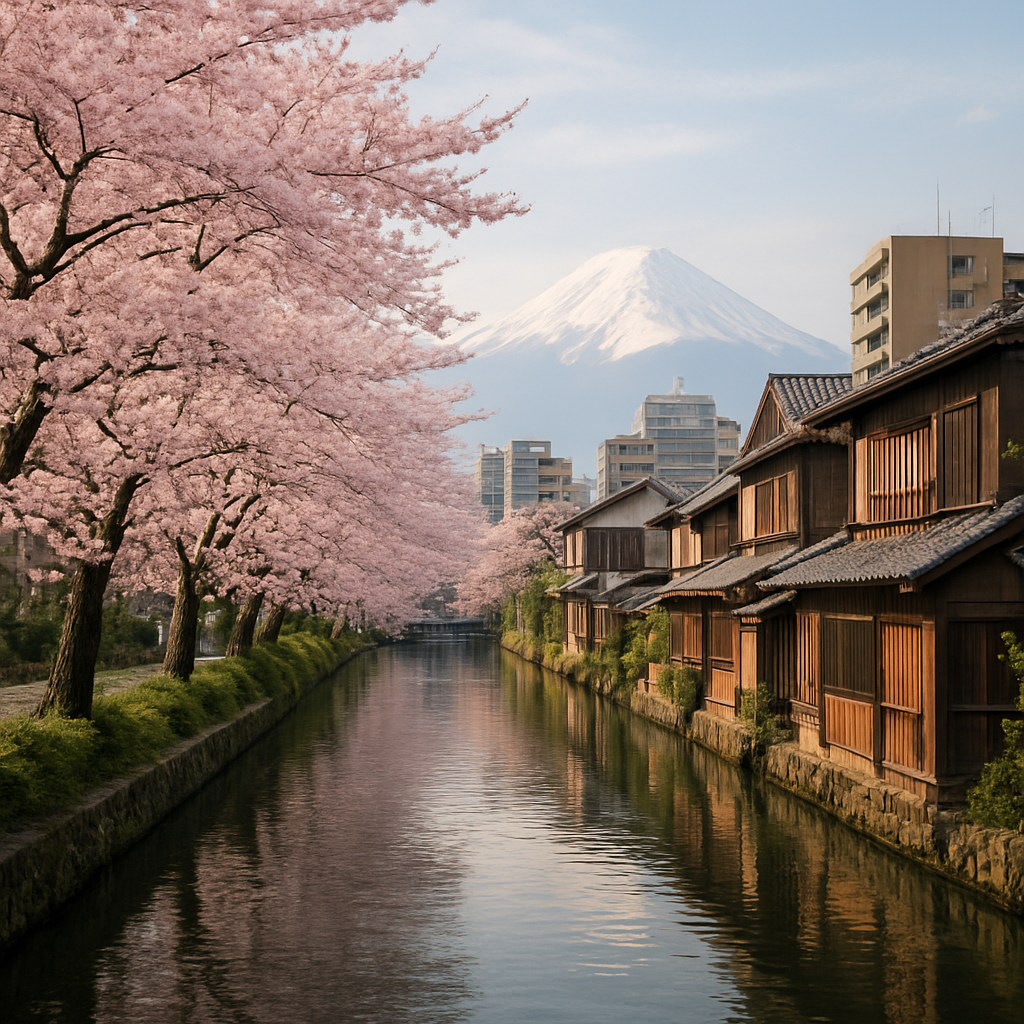

In [80]:
image = artist("tokyo japan") # menjalankan function artist dengan argument ("tokyo japan")
display(image) # fungsi bawaab jupiter- menampilkan image langsung di ouput cell

In [77]:
import requests

def talker(message):
    response = requests.post(
        "https://openrouter.ai/api/v1/audio/speech",
        headers={
            "Authorization": f"Bearer {openai_api_key}",
            "Content-Type": "application/json",
        },
        json={
            "model": "x-ai/grok-voice-tts-1.0",
            "input": message,
            "voice": "ara",
            "response_format": "mp3", 
        },
    )

    if response.status_code != 200:
            print("TTS ERROR:", response.status_code, response.text)  # <-- ini akan bongkar masalahnya
            return None

    print("Content-Type:", response.headers.get("Content-Type"))  # harusnya audio/mpeg
    return response.content

In [54]:
talker("hello test")

TTS ERROR: 400 {"error":{"message":"Model openai/gpt-4o-mini-tts-2025-12-15 does not exist","code":400}}


In [51]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=model, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=model, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])

    return history, voice, image


In [50]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get("destination_city")
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
    return "", history + [{"role": "user", "content": message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7882
* To create a public link, set `share=True` in `launch()`.


Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
DATABASE TOOL CALLED: Getting price for London
Content-Type: audio/mpeg
DATABASE TOOL CALLED: Getting price for paris
Content-Type: audio/mpeg
DATABASE TOOL CALLED: Getting price for Tokyo
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
Content-Type: audio/mpeg
